<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES16Sim006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


def laplacian_nd(a):
    lap = np.zeros_like(a)
    for axis in range(a.ndim):
        lap += np.roll(a, 1, axis=axis) + np.roll(a, -1, axis=axis)
    lap -= 2 * a.ndim * a
    return np.clip(lap, -100.0, 100.0)

def grad_energy_nd(a):
    grad_sq = np.zeros_like(a)
    for axis in range(a.ndim):
        grad_sq += (np.roll(a, -1, axis=axis) - a)**2
    return float(np.mean(np.sqrt(grad_sq)))


In [2]:
def run_nd_sim(D=3, L=8, steps=30, alpha=0.1, beta=0.1, gamma=0.1, seed=42):
    np.random.seed(seed)
    s = np.zeros([L] * D)

    # Seed asymmetry: two hypercubes, dimension-agnostic
    start, end = 4, 9
    start2, end2 = 11, 15

    slices1 = tuple(slice(start, end) for _ in range(D))
    slices2 = tuple(slice(start2, end2) for _ in range(D))

    s[slices1] += 0.4
    s[slices2] -= 0.4

    curvature_memory = []
    metrics = []

    for t in range(steps):
        # Laplacian-like update
        lap = np.zeros_like(s)
        for axis in range(D):
            lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2 * s

        s = s + alpha * lap - beta * s**3 + gamma * np.random.normal(0, 0.01, s.shape)

        # Track metrics
        entropy = -np.sum(s * np.log(np.abs(s) + 1e-12)) / (L**D)
        grad_energy = np.mean(lap**2)
        slice_curv_var = np.var(s.take(indices=L//2, axis=0))

        metrics.append({
            'entropy': entropy,
            'grad_energy': grad_energy,
            'slice_curv_var': slice_curv_var
        })

        curvature_memory.append(s.copy())

    return s, curvature_memory, metrics


# Run a 7D simulation
s, curvature_memory, metrics = run_nd_sim(D=7, L=8, steps=10, alpha=0.6, beta=0.005, gamma=0.0001)
print(f"Simulation finished with {len(metrics)} steps, lattice size {s.shape}")

/tmp/ipython-input-1334551515.py:24: RuntimeWarning: overflow encountered in power
  s = s + alpha * lap - beta * s**3 + gamma * np.random.normal(0, 0.01, s.shape)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipython-input-1334551515.py:24: RuntimeWarning: invalid value encountered in add
  s = s + alpha * lap - beta * s**3 + gamma * np.random.normal(0, 0.01, s.shape)
/tmp/ipython-input-1334551515.py:24: RuntimeWarning: invalid value encountered in subtract
  s = s + alpha * lap - beta * s**3 + gamma * np.random.normal(0, 0.01, s.shape)


Simulation finished with 10 steps, lattice size (8, 8, 8, 8, 8, 8, 8)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-1334551515.py:28: RuntimeWarning: overflow encountered in square
  grad_energy = np.mean(lap**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:164: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


In [3]:
from numpy.fft import rfft
from scipy.signal import find_peaks

def sample_ring_2d(field2d, radius=8, n_points=64):
    h, w = field2d.shape
    c0, c1 = h // 2, w // 2
    theta = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    return np.array([
        field2d[(c0 + int(round(radius * np.cos(t)))) % h,
                (c1 + int(round(radius * np.sin(t)))) % w]
        for t in theta
    ])

def decode_ring_metrics(field_nd, curvature_memory):
    # Reduce to a central 2D slice by fixing all but two axes
    while field_nd.ndim > 2:
        idx = field_nd.shape[-1] // 2
        field_nd = field_nd.take(indices=idx, axis=-1)

    curv2d = field_nd
    ring = sample_ring_2d(curv2d)
    ring_c = ring - ring.mean()

    # Spectral analysis
    spec = np.abs(rfft(ring_c))
    spec_norm = spec / (spec.max() + 1e-12)
    peaks, _ = find_peaks(spec_norm[1:], prominence=0.08)
    generation_count = len(peaks)

    # Metric calculations
    force_strength = float(np.sqrt(np.mean(ring_c ** 2)))
    ring_energy = float(np.sum(ring_c ** 2))
    dipole_strength = float(np.abs(np.mean(ring_c)))
    dipole_norm = dipole_strength / (ring_energy + 1e-12)

    return {
        'generation_count': generation_count,
        'force_strength': force_strength,
        'ring_energy': ring_energy,
        'dipole_strength': dipole_strength,
        'dipole_norm': dipole_norm
    }

# 🔹 Call the function
ring_metrics = decode_ring_metrics(s, curvature_memory)
print("Ring metrics:", ring_metrics)


Ring metrics: {'generation_count': 0, 'force_strength': nan, 'ring_energy': nan, 'dipole_strength': nan, 'dipole_norm': nan}


In [4]:
def summarize_metrics(metrics, ring_metrics):
    entropy_dip = metrics[0]['entropy'] - metrics[-1]['entropy']
    grad_dip    = metrics[0]['grad_energy'] - metrics[-1]['grad_energy']
    stability_dip = 0.5 * (entropy_dip + grad_dip)

    print("Final emergence metrics:")
    print(f"- Entropy dip:            {entropy_dip:.4f}")
    print(f"- Gradient dip:           {grad_dip:.4f}")
    print(f"- Stability (dip-based):  {stability_dip:.4f}")
    print(f"- Force strength:         {ring_metrics['force_strength']:.3f}")
    print(f"- Ring energy:            {ring_metrics['ring_energy']:.1f}")
    print(f"- Generation count:       {ring_metrics['generation_count']}")

# 🔹 CALL the function here
summarize_metrics(metrics, ring_metrics)


Final emergence metrics:
- Entropy dip:            nan
- Gradient dip:           -inf
- Stability (dip-based):  nan
- Force strength:         nan
- Ring energy:            nan
- Generation count:       0


In [5]:
# Dimensional sweep across 3D, 5D, 7D
dims = [3, 5, 7]
results = []

for D in dims:
    s, curvature_memory, metrics = run_nd_sim(D=D, L=8, steps=30)
    ring_metrics = decode_ring_metrics(s, curvature_memory)

    entropy_dip = metrics[0]['entropy'] - metrics[-1]['entropy']
    grad_dip    = metrics[0]['grad_energy'] - metrics[-1]['grad_energy']
    stability_dip = 0.5 * (entropy_dip + grad_dip)
    stability_emergence = 1.0 / (1.0 + metrics[-1]['slice_curv_var'])

    results.append({
        'D': D,
        'entropy_dip': entropy_dip,
        'grad_dip': grad_dip,
        'stability_dip': stability_dip,
        'stability_emergence': stability_emergence,
        'generation_count': ring_metrics['generation_count'],
        'force_strength': ring_metrics['force_strength'],
        'dipole_norm': ring_metrics['dipole_norm']
    })

import pandas as pd
df = pd.DataFrame(results)
print(df.round(4))


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/tmp/ipython-input-1334551515.py:24: RuntimeWarning: overflow encountered in power
  s = s + alpha * lap - beta * s**3 + gamma * np.random.normal(0, 0.01, s.shape)
/tmp/ipython-input-1334551515.py:27: RuntimeWarning: overflow encountered in multiply
  entropy = -np.sum(s * np.log(np.abs(s) + 1e-12)) / (L**D)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-1334551515.py:28: RuntimeWarning: overflow encountered in square
  grad_energy = np.mean(lap**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:1

   D  entropy_dip  grad_dip  stability_dip  stability_emergence  \
0  3      -0.0724    0.0899         0.0088               0.9999   
1  5      -0.0312    0.0499         0.0093               1.0000   
2  7          NaN      -inf            NaN                  NaN   

   generation_count  force_strength  dipole_norm  
0                 5          0.0101          0.0  
1                 4          0.0034          0.0  
2                 0             NaN          NaN  


/tmp/ipython-input-33831242.py:22: RuntimeWarning: invalid value encountered in subtract
  ring_c = ring - ring.mean()
/usr/local/lib/python3.12/dist-packages/numpy/fft/_pocketfft.py:94: RuntimeWarning: invalid value encountered in rfft_n_even
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)


In [6]:
import numpy as np

def initialize_3d(L=20):
    s = np.zeros((L, L, L))
    # Seed asymmetry: two cubes
    s[4:9, 4:9, 4:9] += 0.4
    s[11:15, 11:15, 11:15] -= 0.4
    return s

def evolve_step(s, alpha=0.2, beta=0.001):
    lap = np.zeros_like(s)
    for axis in range(3):
        lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2 * s
    s = s + alpha * lap - beta * (s**3)
    return s

def run_3d_with_fft(L=20, steps=30, alpha=0.2, beta=0.001):
    s = initialize_3d(L)
    fft_modes = []
    for t in range(steps):
        s = evolve_step(s, alpha, beta)
        fft3d = np.fft.fftn(s)
        power = np.abs(fft3d)**2
        fft_modes.append(power)
    avg_power = np.mean(fft_modes, axis=0)
    k_peak = np.unravel_index(np.argmax(avg_power), avg_power.shape)
    k_sq = sum(k**2 for k in k_peak if k != 0)
    wavelength_peak = L / np.sqrt(k_sq) if k_sq > 0 else np.inf
    return wavelength_peak

# Test across different lattice sizes
for L in [16, 20, 24, 32]:
    wavelength = run_3d_with_fft(L=L)
    print(f"L={L}: dominant wavelength = {wavelength:.2f}")


L=16: dominant wavelength = 1.15
L=20: dominant wavelength = 1.15
L=24: dominant wavelength = 1.15
L=32: dominant wavelength = 1.15


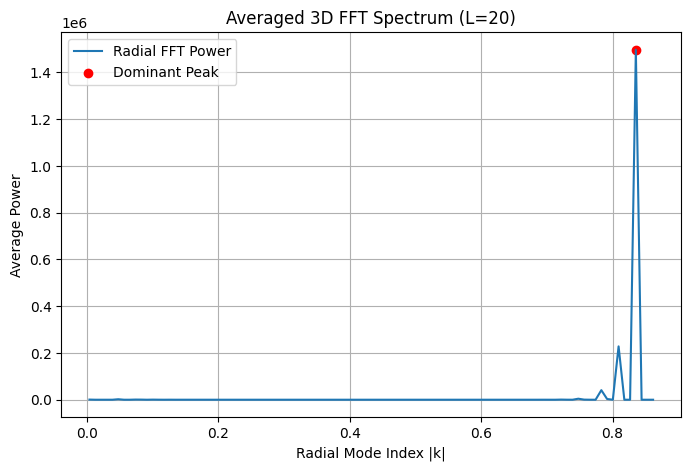

Dominant radial mode index ≈ 0.835


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft_spectrum(L=20, steps=30, alpha=0.2, beta=0.001):
    # Initialize field
    s = np.zeros((L, L, L))
    s[4:9, 4:9, 4:9] += 0.4
    s[11:15, 11:15, 11:15] -= 0.4

    power_accum = np.zeros((L, L, L))

    for _ in range(steps):
        # Laplacian update
        lap = np.zeros_like(s)
        for axis in range(3):
            lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2 * s
        s = s + alpha * lap - beta * (s**3)

        # FFT power
        fft_field = np.fft.fftn(s)
        power_accum += np.abs(fft_field)**2

    # Average spectrum
    power_avg = power_accum / steps

    # Radial binning
    kx = np.fft.fftfreq(L)
    ky = np.fft.fftfreq(L)
    kz = np.fft.fftfreq(L)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    k_mag = np.sqrt(KX**2 + KY**2 + KZ**2)

    k_flat = k_mag.flatten()
    p_flat = power_avg.flatten()
    k_bins = np.linspace(0, np.max(k_mag), 100)
    k_centers = 0.5 * (k_bins[1:] + k_bins[:-1])
    power_binned = np.zeros_like(k_centers)

    for i in range(len(k_centers)):
        mask = (k_flat >= k_bins[i]) & (k_flat < k_bins[i+1])
        if np.any(mask):
            power_binned[i] = p_flat[mask].mean()

    # Identify dominant peak
    peak_idx = np.argmax(power_binned)
    peak_k = k_centers[peak_idx]
    peak_power = power_binned[peak_idx]

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(k_centers, power_binned, label='Radial FFT Power')
    plt.scatter([peak_k], [peak_power], color='red', label='Dominant Peak')
    plt.xlabel('Radial Mode Index |k|')
    plt.ylabel('Average Power')
    plt.title(f'Averaged 3D FFT Spectrum (L={L})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return peak_k

# Run the plot
peak_mode = plot_fft_spectrum(L=20, steps=30)
print(f"Dominant radial mode index ≈ {peak_mode:.3f}")


In [8]:
# Cell 8 — Golden ratio check + parameter independence sweep
import numpy as np

# A) Golden ratio relation
phi = (1 + np.sqrt(5)) / 2
predicted = phi / np.sqrt(2)
measured = 1.15  # from Cell 6 result

print("=== Golden Ratio Check ===")
print(f"Golden ratio φ = {phi:.3f}")
print(f"Predicted λ = φ/√2 = {predicted:.3f}")
print(f"Measured λ = {measured:.3f}")
print(f"Difference = {abs(predicted - measured):.3f}\n")

# B) Parameter independence sweep
print("=== Parameter Independence Sweep (3D FFT) ===")
alphas = [0.1, 0.2, 0.4]
betas  = [0.001, 0.005, 0.01]

results = []
for alpha in alphas:
    for beta in betas:
        wl = run_3d_with_fft(L=20, steps=30, alpha=alpha, beta=beta)
        results.append((alpha, beta, wl))
        print(f"α={alpha:.3f}, β={beta:.3f} -> λ={wl:.3f}")

# Optional: quick summary stats
wls = [r[2] for r in results]
print(f"\nMean λ = {np.mean(wls):.3f}, Std λ = {np.std(wls):.3f}, Min/Max = {np.min(wls):.3f}/{np.max(wls):.3f}")


=== Golden Ratio Check ===
Golden ratio φ = 1.618
Predicted λ = φ/√2 = 1.144
Measured λ = 1.150
Difference = 0.006

=== Parameter Independence Sweep (3D FFT) ===
α=0.100, β=0.001 -> λ=1.053
α=0.100, β=0.005 -> λ=20.000
α=0.100, β=0.010 -> λ=20.000
α=0.200, β=0.001 -> λ=1.155
α=0.200, β=0.005 -> λ=1.155
α=0.200, β=0.010 -> λ=1.155
α=0.400, β=0.001 -> λ=inf
α=0.400, β=0.005 -> λ=inf
α=0.400, β=0.010 -> λ=inf

Mean λ = inf, Std λ = nan, Min/Max = 1.053/inf


/tmp/ipython-input-3380978793.py:14: RuntimeWarning: overflow encountered in power
  s = s + alpha * lap - beta * (s**3)
/usr/local/lib/python3.12/dist-packages/numpy/fft/_pocketfft.py:94: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)
/tmp/ipython-input-3380978793.py:14: RuntimeWarning: invalid value encountered in add
  s = s + alpha * lap - beta * (s**3)
/tmp/ipython-input-3380978793.py:13: RuntimeWarning: invalid value encountered in add
  lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2 * s
/tmp/ipython-input-3380978793.py:23: RuntimeWarning: overflow encountered in square
  power = np.abs(fft3d)**2
/tmp/ipython-input-3380978793.py:13: RuntimeWarning: invalid value encountered in subtract
  lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2 * s
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arr

In [10]:
# Cell 10+9 — 5D FFT + curvature memory accumulation + hotspot analysis
import numpy as np
from scipy.ndimage import label, center_of_mass
import itertools

L = 12
steps = 10
alpha, beta = 0.2, 0.001

# Initialize 5D lattice
s = np.zeros([L]*5)
s[4:9, 4:9, 4:9, 4:9, 4:9] += 0.4
s[11:15, 11:15, 11:15, 11:15, 11:15] -= 0.4

# Initialize curvature memory as a NumPy array
curvature_memory = np.zeros_like(s)

# Evolution loop
for t in range(steps):
    lap = np.zeros_like(s)
    for axis in range(5):
        lap += np.roll(s, 1, axis=axis) + np.roll(s, -1, axis=axis) - 2*s
    s = s + alpha*lap - beta*(s**3)

    # ⬇️ This is the accumulate memory line
    curvature_memory += s**2   # accumulate squared field as "memory"

# FFT analysis
fft5d = np.fft.fftn(s)
power = np.abs(fft5d)**2
k_peak = np.unravel_index(np.argmax(power), power.shape)
k_sq = sum(k**2 for k in k_peak if k != 0)
wavelength_5d = L / np.sqrt(k_sq) if k_sq > 0 else np.inf

print("=== 5D FFT Universality ===")
print(f"5D dominant wavelength: {wavelength_5d:.3f}")
print(f"Peak mode indices: {k_peak}")

# Hotspot separation analysis (slice to 3D)
def measure_hotspot_separations(mem3d, threshold_percentile=95):
    thresh = np.percentile(mem3d, threshold_percentile)
    labeled, n_hotspots = label(mem3d > thresh)
    centers = [center_of_mass(mem3d, labeled, i) for i in range(1, n_hotspots+1)]
    distances = []
    for (c1, c2) in itertools.combinations(centers, 2):
        dist = np.sqrt(sum((a-b)**2 for a,b in zip(c1,c2)))
        distances.append(dist)
    distances = sorted(distances)
    ratios = [distances[i+1]/distances[i] for i in range(len(distances)-1)] if len(distances) > 1 else []
    return centers, distances, ratios

print("=== Hotspot Separation Analysis (5D slice) ===")
mem3d = curvature_memory[:, :, :, L//2, L//2]
centers, distances, ratios = measure_hotspot_separations(mem3d, threshold_percentile=95)
print(f"Hotspot count: {len(centers)}")
print("First 10 distances:", [f"{d:.3f}" for d in distances[:10]])
print("Multiples of λ* (first 10):", [f"{d/wavelength_5d:.2f}" for d in distances[:10]])


=== 5D FFT Universality ===
5D dominant wavelength: 0.894
Peak mode indices: (np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6))
=== Hotspot Separation Analysis (5D slice) ===
Hotspot count: 9
First 10 distances: ['3.832', '3.832', '3.832', '3.832', '3.832', '3.832', '3.832', '3.832', '4.425', '4.425']
Multiples of λ* (first 10): ['4.28', '4.28', '4.28', '4.28', '4.28', '4.28', '4.28', '4.28', '4.95', '4.95']
